# **08 LangGraph 기본 사용법 - 메시지 기반 챗봇**

### 학습 내용
1. LangGraph의 핵심 개념 이해
2. 기본 챗봇 구현
3. invoke와 stream 사용법
4. 2개 노드 연결하여 워크플로우 구성
5. 다단계 번역 시스템 구현

## 0. 환경 설정

In [13]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("API Key가 설정되었습니다.")

API Key가 설정되었습니다.


## 1. [LangGraph](https://docs.langchain.com/oss/python/langgraph/overview) 기본 사용법 - 간단한 챗봇 만들기


### 핵심 구성 요소

1. **State (상태)** - 그래프가 관리하는 데이터
2. **Node (노드)** - 상태를 변경하는 함수
3. **Edge (엣지)** - 노드 간의 연결
4. **Graph (그래프)** - 전체 워크플로우

### 1-1. 그래프 스키마 정의

LangGraph에서 **State**는 그래프가 관리하는 데이터의 스키마입니다.

- **그래프 스키마**: 어떤 데이터를 관리할지 정의
- **리듀서 함수**: 상태 업데이트 방법을 정의 (예: 덮어쓰기, 누적하기)

In [14]:
from typing_extensions import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

📍 챗봇을 만들 때는 **메시지를 누적**해야 하므로, `add_messages` 리듀서를 사용합니다.

> `add_messages`: 메시지를 자동으로 누적하는 **리듀서 함수**
- 메시지 자동 병합
- 중복 메시지 ID 처리
- 메시지 수정 및 삭제 지원

In [15]:
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph.message import add_messages

msgs1 = [HumanMessage(content="Hello", id="1")]
msgs2 = [AIMessage(content="Hi there!", id="2")]
add_messages(msgs1, msgs2)

[HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='1'),
 AIMessage(content='Hi there!', additional_kwargs={}, response_metadata={}, id='2', tool_calls=[], invalid_tool_calls=[])]

In [16]:
# 동일 ID로 메시지 업데이트
msgs1 = [HumanMessage(content="첫 번째 메시지", id="1")]
msgs2 = [HumanMessage(content="수정된 메시지", id="1")]  # 동일 ID

result = add_messages(msgs1, msgs2)

print("\nID가 같은 경우 (메시지 수정):")
for msg in result:
    print(f"{type(msg).__name__} (id={msg.id}): {msg.content}")


ID가 같은 경우 (메시지 수정):
HumanMessage (id=1): 수정된 메시지


### 1-2. 그래프 노드와 엣지 추가 & 컴파일

In [17]:
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from langchain_core.messages import AnyMessage, HumanMessage

# LLM 초기화
llm = init_chat_model("gpt-5.4-mini")

# 챗봇 노드 - 메시지를 받아 LLM 응답 반환
def chatbot(state: State):
    response = llm.invoke(state["messages"])
    return {"messages": response}  # AIMessage 객체 반환

# 그래프 구성
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

### 1-3. 그래프 시각화

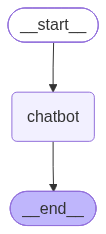

In [18]:
# 그래프 시각화
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

## 2. 그래프 실행 테스트

### 2-1. invoke - 일반 호출

`invoke`는 동기 방식으로 그래프를 실행하고 최종 결과를 반환합니다.

In [19]:
# invoke - 동기 방식
user_message = HumanMessage("안녕하세요! Python의 장점을 3가지만 알려주세요.")
result = graph.invoke({"messages": [user_message]})

print("[invoke 결과]")
for msg in result["messages"]:
    msg.pretty_print()

[invoke 결과]
================================ Human Message =================================

안녕하세요! Python의 장점을 3가지만 알려주세요.
================================== Ai Message ==================================

안녕하세요! Python의 장점 3가지는 다음과 같습니다.

1. **문법이 간단하고 읽기 쉽다**  
   Python은 코드가 비교적 직관적이라 초보자도 배우기 쉽고, 유지보수도 편합니다.

2. **활용 분야가 매우 넓다**  
   웹 개발, 데이터 분석, 인공지능, 자동화, 과학 계산 등 다양한 분야에서 사용할 수 있습니다.

3. **풍부한 라이브러리와 커뮤니티가 있다**  
   필요한 기능을 빠르게 구현할 수 있는 라이브러리가 많고, 문제를 해결할 때 참고할 자료도 풍부합니다.

원하시면 **초보자 관점**, **취업 관점**, 또는 **다른 언어와 비교해서**도 설명해드릴게요.


### 2-2. stream - 스트리밍 호출

`stream`은 중간 결과를 실시간으로 반환합니다.

### 스트림 모드

- **values**: 각 단계의 전체 상태 출력
- **updates**: 각 단계의 업데이트만 출력 (기본값)
- **messages**: 메시지와 메타데이터 출력 (스트리밍 텍스트)

In [20]:
# stream_mode="messages" - 스트리밍 텍스트 출력
print("\n[stream - messages 모드]")
user_message = HumanMessage("LangGraph란 무엇인가요?")

for chunk_msg, metadata in graph.stream({"messages": [user_message]}, stream_mode="messages"):
    print(chunk_msg.content, end="", flush=True)


[stream - messages 모드]
LangGraph는 **LLM(대규모 언어 모델) 기반 애플리케이션을 “그래프 구조”로 설계·실행**할 수 있게 해주는 프레임워크입니다.  
보통 LangChain과 함께 많이 언급되며, 특히 **여러 단계의 작업 흐름, 조건 분기, 반복, 상태 관리**가 필요한 AI 에이전트에 잘 맞습니다.

## 핵심 개념
- **Node(노드)**: 실행 단위입니다. 예: 질문 분류, 검색, 답변 생성
- **Edge(엣지)**: 노드 간 이동 경로입니다.
- **State(상태)**: 그래프 전체에서 공유되는 정보입니다. 예: 사용자 질문, 검색 결과, 중간 추론 결과
- **Conditional routing**: 조건에 따라 다른 노드로 이동할 수 있습니다.
- **Cycle/Loop**: 단순한 체인과 달리 반복 구조를 만들 수 있습니다.

## 왜 쓰나요?
일반적인 LLM 앱은 “입력 → 모델 → 출력”처럼 단순한 흐름이 많지만, 실제 에이전트는 보통:
- 질문을 분류한 뒤
- 필요하면 검색하고
- 결과를 검증하고
- 부족하면 다시 검색하거나
- 다른 도구를 호출

같은 복잡한 흐름이 필요합니다.  
LangGraph는 이런 **복잡하고 상태가 있는 워크플로우**를 구현하기 좋습니다.

## 장점
- **복잡한 에이전트 로직을 명시적으로 표현**
- **상태 유지가 쉬움**
- **분기/반복/재시도** 구현에 적합
- **디버깅과 유지보수**가 비교적 쉬움

## 간단한 예시
예를 들어:
1. 사용자의 질문을 받음
2. 질문이 간단하면 바로 답변
3. 정보가 필요하면 검색 도구 호출
4. 검색 결과를 바탕으로 답변 생성

이런 흐름을 LangGraph로 그래프처럼 구성할 수 있습니다.

## 한 줄 요약
**LangGraph는 LLM 앱과 AI 에이전트를 상태 기반 그래프로 구성해, 복잡한 작업 흐름을 안정적으로 구현하게 해주는 프레임워크입니다.**

원하시면 제가 이어서  
- **LangChain과 LangGraph

## 3. 여러 노드 연결 - 답변 생성 + 포맷팅

답변을 생성한 후, 추가 정보를 덧붙이는 2단계 워크플로우를 구현합니다.

In [21]:
from langchain_core.messages import SystemMessage

# State 정의
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

llm = init_chat_model("gpt-5.4-mini")

# 1단계: 답변 생성 노드
def generate_answer(state: State):
    print("답변 생성 중...")
    response = llm.invoke(state["messages"])
    return {"messages": response}

# 2단계: 포맷팅 노드 - 추가 정보 덧붙이기
def format_answer(state: State):
    print("포맷팅 중...")
    suffix = "\n\n---\n추가 문의가 필요하시다면 챗봇 담당자(example@gmail.com)에게 연락 부탁드립니다."
    # 메시지로 추가
    from langchain_core.messages import AIMessage
    return {"messages": [AIMessage(content=suffix)]}

# 그래프 구성
graph_builder = StateGraph(State)
graph_builder.add_node("generate_answer", generate_answer)
graph_builder.add_node("format_answer", format_answer)

graph_builder.add_edge(START, "generate_answer")
graph_builder.add_edge("generate_answer", "format_answer")
graph_builder.add_edge("format_answer", END)

graph = graph_builder.compile()

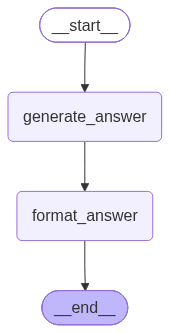

In [22]:
# 시각화
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [23]:
# 실행
user_message = HumanMessage("넌 어떤 기능이 있어?")
result = graph.invoke({"messages": [user_message]})

print("\n" + "="*50)
print("최종 결과:")
for msg in result["messages"]:
    msg.pretty_print()

답변 생성 중...
포맷팅 중...

최종 결과:
================================ Human Message =================================

넌 어떤 기능이 있어?
================================== Ai Message ==================================

나는 여러 가지 일을 할 수 있어. 예를 들면:

- **질문 답변**: 지식, 개념, 비교, 요약
- **글쓰기**: 이메일, 자기소개서, 보고서, 발표문, 문장 다듬기
- **번역**: 한국어 ↔ 영어 등 자연스럽게 번역
- **코딩 도움**: 코드 작성, 오류 분석, 디버깅, 설명
- **학습 도우미**: 어려운 내용을 쉽게 풀어 설명
- **아이디어 제안**: 기획, 브레인스토밍, 이름 짓기
- **정리/요약**: 긴 글을 핵심만 정리
- **대화**: 가벼운 상담, 연습 대화, 역할극

원하면 바로 해볼 수 있어.  
예를 들어:

- “이 문장 자연스럽게 고쳐줘”
- “파이썬으로 이거 어떻게 해?”
- “이 글 3줄로 요약해줘”
- “영어로 번역해줘”

원하는 걸 말해줘.
================================== Ai Message ==================================



---
추가 문의가 필요하시다면 챗봇 담당자(example@gmail.com)에게 연락 부탁드립니다.


## 4. 다단계 번역 시스템 (MessageState 활용)

영어 → 한국어 → 일본어로 순차 번역하는 시스템을 **messages 상태키만** 사용하여 구현합니다.

**설계**:
1. 사용자가 영어 메시지 입력
2. `translate_to_korean` 노드: 한국어로 번역
3. `translate_to_japanese` 노드: 일본어로 번역
4. 모든 메시지가 누적되어 번역 과정 전체를 확인 가능

In [24]:
# State 정의
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


In [25]:
llm = init_chat_model("gpt-5.4-mini")

# 영어 → 한국어 번역 노드
def translate_to_korean(state: State):
    print("영어 → 한국어 번역 중...")

    # 마지막 메시지가 번역할 원문
    original_text = state["messages"][-1].content

    messages = [
        SystemMessage(content="You are a professional translator. Translate the given English text to Korean. Return only the translation."),
        HumanMessage(content=original_text)
    ]

    response = llm.invoke(messages)
    print(f"한국어 번역: {response.content}")

    return {"messages": [response]}

# 한국어 → 일본어 번역 노드
def translate_to_japanese(state: State):
    print("한국어 → 일본어 번역 중...")

    # 마지막 메시지가 한국어 번역본
    korean_text = state["messages"][-1].content

    messages = [
        SystemMessage(content="You are a professional translator. Translate the given Korean text to Japanese. Return only the translation."),
        HumanMessage(content=korean_text)
    ]

    response = llm.invoke(messages)
    print(f"일본어 번역: {response.content}")

    return {"messages": [response]}

In [26]:
# 그래프 구성
graph_builder = StateGraph(State)
graph_builder.add_node("translate_to_korean", translate_to_korean)
graph_builder.add_node("translate_to_japanese", translate_to_japanese)

graph_builder.add_edge(START, "translate_to_korean")
graph_builder.add_edge("translate_to_korean", "translate_to_japanese")
graph_builder.add_edge("translate_to_japanese", END)

graph = graph_builder.compile()

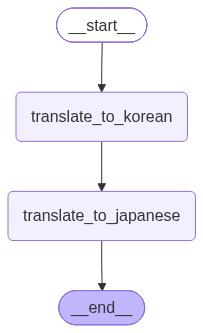

In [27]:
# 시각화
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [28]:
# 실행
input_text = "Hello, how are you?"
result = graph.invoke({"messages": [HumanMessage(content=input_text)]})

# 결과 출력
print("\n" + "="*50)
print("번역 결과:")
print(f"총 {len(result['messages'])}개의 메시지")
print()
for i, msg in enumerate(result["messages"], 1):
    print(f"{i}. {type(msg).__name__}: {msg.content}")

영어 → 한국어 번역 중...
한국어 번역: 안녕하세요, 어떻게 지내세요?
한국어 → 일본어 번역 중...
일본어 번역: こんにちは、お元気ですか？

번역 결과:
총 3개의 메시지

1. HumanMessage: Hello, how are you?
2. AIMessage: 안녕하세요, 어떻게 지내세요?
3. AIMessage: こんにちは、お元気ですか？


In [29]:
input_text = "Hello, how are you?"
user_message = HumanMessage(input_text)

for chunk in graph.stream({"messages": [user_message]}, stream_mode="updates"):
    for node, msg in chunk.items():
        print(f"[{node}] {msg['messages'][-1].content}")
        print("=" * 50)

영어 → 한국어 번역 중...
한국어 번역: 안녕하세요, 어떻게 지내세요?
[translate_to_korean] 안녕하세요, 어떻게 지내세요?
한국어 → 일본어 번역 중...
일본어 번역: こんにちは、お元気ですか？
[translate_to_japanese] こんにちは、お元気ですか？


---

### 참고 자료

- [LangGraph 공식 문서](https://langchain-ai.github.io/langgraph/)
- [LangGraph State 가이드](https://langchain-ai.github.io/langgraph/concepts/low_level/#state)
- [LangGraph add_messages](https://langchain-ai.github.io/langgraph/concepts/low_level/#add_messages)